## Sub - Data Understanding
 - We will investigate and understand the sub-data that we did from previous notebook as we took a subset from the dataset ( current from 2023 - 2026)
 - We will use as reference **Blueprints for Text Analytics using python**
 - We will first get an overview of the Data with Pandas
    - Calculate summary statistics
    - Check for missing values
    - Plot distributions of intersting attributes ('Costumer narrative complaint')

In [30]:
#Importing libraries
import pandas as pd
import regex as re
import nltk
from collections import Counter

In [4]:
data = pd.read_csv('final.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2313445 entries, 0 to 2313444
Data columns (total 17 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Unnamed: 0                    int64
 1   Date received                 str  
 2   Product                       str  
 3   Sub-product                   str  
 4   Issue                         str  
 5   Sub-issue                     str  
 6   Consumer complaint narrative  str  
 7   Company public response       str  
 8   Company                       str  
 9   State                         str  
 10  ZIP code                      str  
 11  Tags                          str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Complaint ID                  int64
dtypes: int64(2), str(15)
memory usage: 300.1 MB


In [11]:
df = data.drop(['Unnamed: 0'],axis=1)
df['Date received'] = pd.to_datetime(df['Date received'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2313445 entries, 0 to 2313444
Data columns (total 16 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Date received                 datetime64[us]
 1   Product                       str           
 2   Sub-product                   str           
 3   Issue                         str           
 4   Sub-issue                     str           
 5   Consumer complaint narrative  str           
 6   Company public response       str           
 7   Company                       str           
 8   State                         str           
 9   ZIP code                      str           
 10  Tags                          str           
 11  Submitted via                 str           
 12  Date sent to company          str           
 13  Company response to consumer  str           
 14  Timely response?              str           
 15  Complaint ID                  int64        

In [20]:
df['length'] = df['Consumer complaint narrative'].str.len()
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date received,2313445,2025-01-13 01:23:11.301198,2023-08-25 00:00:00,2024-07-20 00:00:00,2025-01-30 00:00:00,2025-07-14 00:00:00,2026-07-27 00:00:00,NaN
Complaint ID,2313445.0,12364980.651842,7451721.0,9565619.0,11855457.0,14632606.0,24635023.0,3359282.425927
length,2313445.0,1016.407668,10.0,331.0,662.0,1217.0,35984.0,1308.620875


In [21]:
df.isna().sum()

Date received                         0
Product                               0
Sub-product                           0
Issue                                 0
Sub-issue                        117957
Consumer complaint narrative          0
Company public response         1053091
Company                               0
State                              8191
ZIP code                            255
Tags                            2154003
Submitted via                         0
Date sent to company                  0
Company response to consumer          7
Timely response?                      0
Complaint ID                          0
length                                0
dtype: int64

<Axes: >

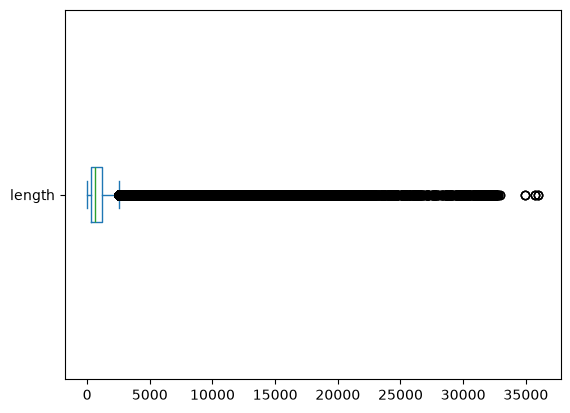

In [22]:
df['length'].plot(kind='box', vert=False)

<Axes: ylabel='Frequency'>

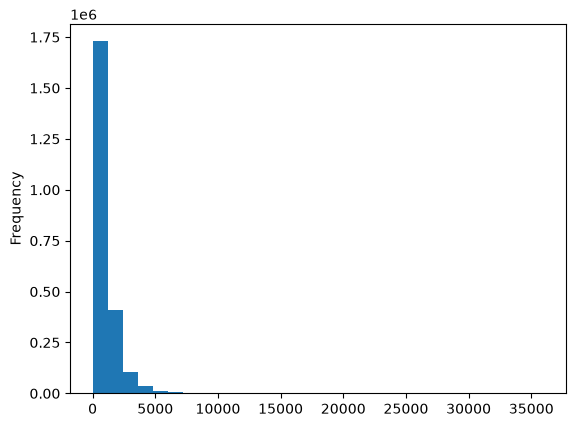

In [23]:
df['length'].plot(kind='hist',bins=30)

## Performing Tokenization with Regular Expressions
 We will create a pipeline that have three steps :
  - Case-Folding
  - Tokenization
  - Stop word removal
 
 -> We will get prepared tokens 

In [26]:
def tokenize(text):
    return re.findall(r'[\w-]*\p{L}[\w-]*',text)
stopwords = set(nltk.corpus.stopwords.words('english'))
def remove_stop(tokens):
    return [ t for t in tokens if t.lower() not in stopwords]
pipeline = [str.lower,tokenize,remove_stop]
def prepare(text,pipeline):
    tokens = text
    for transform in pipeline :
        tokens = transform(tokens)
    return tokens

In [28]:
df['tokens'] = df['Consumer complaint narrative'].apply(prepare,pipeline=pipeline)

In [31]:
counter = Counter()
df['tokens'].map(counter.update)

0          None
1          None
2          None
3          None
4          None
           ... 
2313440    None
2313441    None
2313442    None
2313443    None
2313444    None
Name: tokens, Length: 2313445, dtype: object

In [32]:
print(counter.most_common(5))

[('xxxx', 32372354), ('credit', 5020980), ('xx', 4251390), ('account', 3283667), ('report', 3173205)]
